In [1]:
# Trading Strategy with bull ratio condition, if bull ratio > 1.5 only then buy

In [17]:
import numpy as np
import pandas as pd

In [16]:
from google.colab import files
uploaded = files.upload()

Saving master_df_9.csv to master_df_9.csv


In [18]:
master_df = pd.read_csv('master_df_9.csv')

In [19]:
master_df

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,Index_Close,Signal,RV,Alpha,Beta
0,01-09-2023,ADANIENT,2308.30,2390.30,2307.40,2375.30,2375.30,6977306,19435.30,0,0.492104,0.000511,1.731331
1,01-09-2023,ADANIPORTS,780.00,808.00,779.65,799.50,799.50,11900199,19435.30,0,0.364817,-0.000234,1.549004
2,01-09-2023,APOLLOHOSP,4840.00,4849.95,4801.20,4840.35,4840.35,206097,19435.30,0,0.149016,-0.000260,0.831147
3,01-09-2023,ASIANPAINT,3241.10,3264.20,3217.10,3259.55,3259.55,650131,19435.30,0,0.136749,-0.000202,0.705276
4,01-09-2023,AXISBANK,974.25,993.00,969.00,991.15,991.15,10946742,19435.30,0,0.150442,0.000183,1.026563
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27350,28-11-2025,TITAN,3906.20,3934.90,3896.50,3907.70,3907.70,574817,26202.95,0,0.124132,-0.000159,0.741249
27351,28-11-2025,TMPV,358.00,359.75,355.10,356.80,356.80,10905212,26202.95,0,0.297689,-0.001238,1.188538
27352,28-11-2025,TRENT,4276.10,4283.20,4236.80,4250.40,4250.40,549814,26202.95,0,0.158791,0.000226,1.191395
27353,28-11-2025,ULTRACEMCO,11620.00,11640.00,11557.00,11600.00,11600.00,159990,26202.95,1,0.136439,-0.000037,1.047637


In [21]:
import numpy as np
import pandas as pd

# # FIX DATE
master_df["Date"] = pd.to_datetime(master_df["Date"], format="%d-%m-%Y")
master_df["Date"] = pd.to_datetime(master_df["Date"], yearfirst=True)
# sort first (very important)
master_df = master_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

bull = (
    master_df
    .groupby('Ticker')['Signal']
    .rolling(44)
    .sum()
    .reset_index(level=0, drop=True)
)

bear = (
    master_df
    .groupby('Ticker')['Signal']
    .rolling(44)
    .apply(lambda x: (x == 0).sum())
    .reset_index(level=0, drop=True)
)

master_df['Bull_Ratio_44'] = bull / bear.replace(0, np.nan)


In [22]:
master_df = master_df.dropna().reset_index(drop=True)


In [24]:
master_df

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,Index_Close,Signal,RV,Alpha,Beta,Bull_Ratio_44
0,2023-11-06,ADANIENT,2185.20,2191.00,2164.90,2177.50,2177.50,794299,19411.75,0,0.336314,0.000500,1.684270,0.629630
1,2023-11-07,ADANIENT,2188.10,2191.00,2158.70,2165.20,2165.20,661747,19406.70,1,0.344076,0.000393,1.683830,0.692308
2,2023-11-08,ADANIENT,2176.80,2227.90,2166.80,2191.00,2191.00,1205980,19443.50,0,0.301464,0.000352,1.684462,0.629630
3,2023-11-09,ADANIENT,2199.80,2203.30,2142.70,2147.10,2147.10,1307797,19395.30,1,0.289021,0.000331,1.688463,0.692308
4,2023-11-10,ADANIENT,2152.50,2168.70,2131.40,2137.80,2137.80,1106357,19425.35,0,0.280486,0.000293,1.688863,0.629630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25193,2025-11-24,WIPRO,245.02,249.38,245.02,247.27,247.27,19711070,25959.50,1,0.171141,-0.000121,1.054951,4.500000
25194,2025-11-25,WIPRO,248.00,248.00,244.00,245.64,245.64,8188793,25884.80,1,0.166798,-0.000082,1.053098,4.500000
25195,2025-11-26,WIPRO,246.00,250.55,245.62,250.19,250.19,8202096,26205.30,1,0.171066,-0.000113,1.049779,4.500000
25196,2025-11-27,WIPRO,250.40,251.92,247.69,249.56,249.56,5268129,26215.55,0,0.180047,-0.000133,1.051148,3.888889


In [25]:
import pandas as pd
import numpy as np
import math

# ---------- USER INPUT / CONFIG ----------
N = 10
multiple = 1

# Initial capital (10 lakh)
INITIAL_CAPITAL = 1_000_000.0

# Ensure Date column is datetime
master_df['Date'] = pd.to_datetime(master_df['Date'])
# top5_df['Date'] = pd.to_datetime(top5_df['Date'])

# Sort first (VERY important)
master_df = master_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# --- (Keep your top-N selection code as-is; assuming top5_df already produced) ---
# If not, recreate top5_df from master_df using your approach:
master_df_sorted = master_df.sort_values(by=['Date', 'Bull_Ratio_44'], ascending=[True, False])
top5_df = master_df_sorted.groupby('Date').head(N).reset_index(drop=True)
top5_df = top5_df[['Date','Ticker','Close','High','Signal','RV','Bull_Ratio_44']]
top5_df['Date'] = pd.to_datetime(top5_df['Date'])
# ---------- PREP ----------
top5_df = top5_df.sort_values('Date').reset_index(drop=True)
master_df = master_df.sort_values(['Date','Ticker']).reset_index(drop=True)

# Lookups
master_price = master_df.set_index(['Date','Ticker'])['Close']
master_high  = master_df.set_index(['Date','Ticker'])['High']

trade_dates = sorted(top5_df['Date'].unique())

# ---------- STATE ----------
portfolio = {}     # key = ticker, value = dict with Qty, Buy_Price, Buy_Date, etc.
trade_log = []     # list of trades with qty, invested, proceeds, pnl, etc.

# Cash & allocation
cash = float(INITIAL_CAPITAL)
per_slot = float(INITIAL_CAPITAL) / N  # target money allocated per open slot

# ---------- BUY FUNCTION ----------
def buy_ticker(buy_date, ticker, rv, bull_ratio):
    global cash

    # price lookup (use Close on buy_date)
    try:
        buy_price = float(master_price.loc[(buy_date, ticker)])
    except KeyError:
        return False

    # determine target budget for this slot = per_slot
    # target_budget = per_slot
    target_budget = min(dynamic_per_slot, cash)

    # if cash < per_slot -> we cannot buy full allocation; only buy if cash >= some minimum (>= price)
    if cash < buy_price:
        return False

    # compute max integer shares we can buy with budget but limited by available cash
    # spend_at_most = min(target_budget, cash)  # keep strict per_slot allocation
    # To follow "use sale proceeds + spare change" but maintain per_slot weighting,
    # allow spending up to min(per_slot, cash).
    # spend_at_most = min(target_budget, cash)
    spend_at_most = target_budget


    qty = int(math.floor(spend_at_most / buy_price))

    # if qty zero, don't buy
    if qty <= 0:
        return False

    cost = round(qty * buy_price, 2)
    # trailing stop percent & SL compute (your original method)
    SL_Per = float(rv) * multiple * 10
    STOP_LOSS = (SL_Per / 100) * buy_price

    peak_price = buy_price
    current_sl = round(peak_price - STOP_LOSS, 6)

    # Deduct cash by cost
    cash -= cost

    portfolio[ticker] = {
        'Buy_Date': buy_date,
        'Buy_Price': round(buy_price, 6),
        'Qty': qty,
        'Invested': cost,
        'RV': float(rv),
        'Bull_Ratio_44': float(bull_ratio),
        'SL_%': SL_Per,
        'peak_price': round(peak_price, 6),
        'current_sl': round(current_sl, 6),
        'initial_sl': round(current_sl, 6)
    }

    return True


# ---------- SELL FUNCTION ----------
def sell_ticker(sell_date, ticker, sell_price, reason="SL HIT"):
    global cash
    pos = portfolio.pop(ticker)
    qty = pos['Qty']
    buy_price = pos['Buy_Price']
    invested = pos.get('Invested', round(qty * buy_price, 2))

    sell_proceeds = round(qty * sell_price, 2)
    realized_pnl = round((sell_price - buy_price) * qty, 2)

    # add proceeds to cash (use to buy new positions)
    cash += sell_proceeds

    trade_log.append({
        "Buy_Date": pos['Buy_Date'],
        "Sell_Date": sell_date,
        "Ticker": ticker,
        "Qty": qty,
        "Buy_Price": buy_price,
        "Invested": invested,
        "Sell_Price": round(sell_price, 6),
        "Sell_Proceeds": sell_proceeds,
        "Peak_Price": pos['peak_price'],
        "Initial_SL": pos['initial_sl'],
        "Trailing_SL": pos['current_sl'],
        "RV": pos['RV'],
        "Bull_Ratio_44": pos['Bull_Ratio_44'],
        "SL_%": pos['SL_%'],
        "Realized_PnL": realized_pnl,
        "Status": reason
    })


# ---------- MAIN LOOP ----------
for current_date in trade_dates:

    # 1) TRACK existing positions (update peaks, trailing SL, check SL hits on CLOSE)
    for ticker, pos in list(portfolio.items()):

        try:
            today_close = float(master_price.loc[(current_date, ticker)])
            today_high  = float(master_high.loc[(current_date, ticker)])
        except KeyError:
            # no data today for ticker
            continue

        # UPDATE PEAK FROM HIGH
        if today_high > pos['peak_price']:
            pos['peak_price'] = round(today_high, 6)
            # trailing SL uses BUY_PRICE in your original logic
            pos['current_sl'] = round(
                pos['peak_price'] - ((pos['SL_%'] / 100) * pos['Buy_Price']), 6
            )

        # SL HIT CHECK (USING CLOSE)
        if today_close <= pos['current_sl']:
            sell_price = pos['current_sl']
            sell_ticker(current_date, ticker, sell_price, reason="SL HIT")
            continue

    # 2) FILL VACANCIES
    vacancies = N - len(portfolio)

    if vacancies > 0:
        available_capital = cash

    # ✅ Allocate only available money into new slots
        dynamic_per_slot = available_capital / vacancies

        # candidates = top5_df[top5_df['Date'] == current_date].copy()
        # pick only candidates with Bull_Ratio_44 > 1.5
        candidates = top5_df[
            (top5_df['Date'] == current_date) &
            (top5_df['Bull_Ratio_44'] > 1.2)
        ].copy()

        candidates = candidates.sort_values(
            by=['Bull_Ratio_44', 'RV', 'Signal', 'Close'],
            ascending=[False, True, False, True]
        )

        for _, cand in candidates.iterrows():
            if vacancies <= 0:
                break

            cand_ticker = cand['Ticker']
            cand_rv     = float(cand['RV'])
            cand_br     = float(cand['Bull_Ratio_44'])

            if cand_ticker in portfolio:
                continue

            # Try to buy using buy_ticker (it will only buy if cash >= price and sufficient)
            bought = buy_ticker(current_date, cand_ticker, cand_rv, cand_br)

            if bought:
                vacancies -= 1

# ---------- AFTER LOOP: RUNNING POSITIONS (mark-to-market) ----------
# For any running positions, value them at last available close and add to running trade_log as RUNNING rows
for ticker, pos in list(portfolio.items()):

    mask = (master_df['Ticker'] == ticker)

    if mask.sum() == 0:
        last_close = pos['Buy_Price']
        last_date  = pos['Buy_Date']
    else:
        last_row   = master_df[mask].iloc[-1]
        last_close = float(last_row['Close'])
        last_date  = last_row['Date']

    qty = pos['Qty']
    invested = pos.get('Invested', round(qty * pos['Buy_Price'], 2))
    market_value = round(qty * last_close, 2)
    unrealized_pnl = round((last_close - pos['Buy_Price']) * qty, 2)

    trade_log.append({
        "Buy_Date": pos['Buy_Date'],
        "Sell_Date": None,
        "Ticker": ticker,
        "Qty": qty,
        "Buy_Price": pos['Buy_Price'],
        "Invested": invested,
        "Sell_Price": round(last_close, 6),
        "Sell_Proceeds": market_value,
        "Peak_Price": pos['peak_price'],
        "Initial_SL": pos['initial_sl'],
        "Trailing_SL": pos['current_sl'],
        "RV": pos['RV'],
        "Bull_Ratio_44": pos['Bull_Ratio_44'],
        "SL_%": pos['SL_%'],
        "Realized_PnL": None,
        "Unrealized_PnL": unrealized_pnl,
        "Status": "RUNNING"
    })

# ---------- FINAL OUTPUT ----------
trade_summary = pd.DataFrame(trade_log)

if not trade_summary.empty:
    trade_summary['Buy_Date']  = pd.to_datetime(trade_summary['Buy_Date'])
    trade_summary['Sell_Date'] = pd.to_datetime(trade_summary['Sell_Date'])

    trade_summary = trade_summary.sort_values(by=['Buy_Date', 'Sell_Date'], ascending=[True, True]).reset_index(drop=True)

    # Realized PnL column (fill NaNs for running positions)
    if 'Realized_PnL' in trade_summary.columns:
        trade_summary['Realized_PnL'] = trade_summary['Realized_PnL'].fillna(0.0)
    else:
        trade_summary['Realized_PnL'] = 0.0

    # cumulative realized pnl (only for closed trades)
    trade_summary['Cumulative_Realized_PnL'] = trade_summary['Realized_PnL'].cumsum().round(2)

else:
    # empty frame case
    trade_summary = pd.DataFrame(columns=[
        "Buy_Date","Sell_Date","Ticker","Qty","Buy_Price","Invested","Sell_Price",
        "Sell_Proceeds","Peak_Price","Initial_SL","Trailing_SL","RV","Bull_Ratio_44",
        "SL_%","Realized_PnL","Status"
    ])

# Summary metrics
total_qty_bought = int(trade_summary['Qty'].sum())
total_invested = float(trade_summary['Invested'].sum())
realized_pnl = float(trade_summary['Realized_PnL'].sum())
# unrealized pnl from running positions (if present)
if 'Unrealized_PnL' in trade_summary.columns:
    unrealized_pnl = float(trade_summary['Unrealized_PnL'].fillna(0.0).sum())
else:
    unrealized_pnl = 0.0

# final account value = cash (spare) + market value of running positions (Sell_Proceeds for rows with Status RUNNING)
running_mask = trade_summary['Status'] == "RUNNING"
running_value = float(trade_summary.loc[running_mask, 'Sell_Proceeds'].sum()) if running_mask.any() else 0.0
final_account_value = round(cash + running_value, 2)

print("\n✅ FINAL TRADE SUMMARY (top rows)")
print(trade_summary.head(50))   # show top rows; adjust as needed

print("\n📊 PORTFOLIO / ACCOUNT SUMMARY")
print(f"Initial Capital         : {INITIAL_CAPITAL:,.2f}")
print(f"Cash (spare change)     : {cash:,.2f}")
print(f"Market Value (running)  : {running_value:,.2f}")
print(f"Final Account Value     : {final_account_value:,.2f}")
print(f"Total Qty Bought        : {total_qty_bought}")
print(f"Total Invested (sum)    : {total_invested:,.2f}")
print(f"Realized PnL (closed)   : {realized_pnl:,.2f}")
print(f"Unrealized PnL (open)   : {unrealized_pnl:,.2f}")

# If you want to export results:
# trade_summary.to_csv("trade_summary_with_qty.csv", index=False)



✅ FINAL TRADE SUMMARY (top rows)
     Buy_Date  Sell_Date      Ticker  Qty  Buy_Price   Invested   Sell_Price  \
0  2023-11-06 2023-11-08  BAJFINANCE  132     756.00   99792.00   748.623936   
1  2023-11-06 2023-11-10         TCS   29    3380.25   98027.25  3341.603063   
2  2023-11-06 2023-11-15   COALINDIA  339     294.65   99886.35   326.465580   
3  2023-11-06 2023-11-17    HINDALCO  207     481.95   99763.65   501.459315   
4  2023-11-06 2023-11-17    AXISBANK   99    1009.40   99930.60  1019.616222   
5  2023-11-06 2023-11-22   KOTAKBANK   57    1740.20   99191.40  1749.647629   
6  2023-11-06 2023-11-29   EICHERMOT   28    3510.95   98306.60  3825.298471   
7  2023-11-06 2023-12-06  BAJAJ-AUTO   18    5273.00   94914.00  5962.030693   
8  2023-11-06 2023-12-07       TRENT   44    2233.20   98260.80  2851.451340   
9  2023-11-06 2023-12-12    HDFCBANK  133     747.20   99377.60   820.344609   
10 2023-11-08 2023-11-15  BAJFINANCE  149     746.00  111154.00   732.269942   
11 202

In [26]:
trade_summary

,Buy_Date,Sell_Date,Ticker,Qty,Buy_Price,Invested,Sell_Price,Sell_Proceeds,Peak_Price,Initial_SL,Trailing_SL,RV,Bull_Ratio_44,SL_%,Realized_PnL,Status,Unrealized_PnL,Cumulative_Realized_PnL
0,2023-11-06,2023-11-08,BAJFINANCE,132,756.00,99792.00,748.623936,98818.36,764.00,740.623936,748.623936,0.203387,1.315789,2.033871,-973.64,SL HIT,NaN,-973.64
1,2023-11-06,2023-11-10,TCS,29,3380.25,98027.25,3341.603063,96906.49,3404.15,3317.703063,3341.603063,0.185036,2.384615,1.850364,-1120.76,SL HIT,NaN,-2094.40
2,2023-11-06,2023-11-15,COALINDIA,339,294.65,99886.35,326.465580,110671.83,334.20,286.915580,326.465580,0.262495,1.588235,2.624952,10785.48,SL HIT,NaN,8691.08
3,2023-11-06,2023-11-17,HINDALCO,207,481.95,99763.65,501.459315,103802.08,513.50,469.909315,501.459315,0.249833,1.588235,2.498327,4038.43,SL HIT,NaN,12729.51
4,2023-11-06,2023-11-17,AXISBANK,99,1009.40,99930.60,1019.616222,100942.01,1045.00,984.016222,1019.616222,0.251474,1.588235,2.514739,1011.41,SL HIT,NaN,13740.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933,2025-11-25,NaT,ICICIBANK,319,1357.80,433138.20,1388.800000,443027.20,1398.50,1338.898627,1379.598627,0.139206,1.315789,1.392059,0.00,RUNNING,9889.0,3261955.55
934,2025-11-27,2025-11-28,ADANIENT,184,2255.00,414920.00,2289.248349,421221.70,2331.00,2213.248349,2289.248349,0.185151,1.588235,1.851514,6301.70,SL HIT,NaN,3268257.25
935,2025-11-28,NaT,HDFCLIFE,560,764.30,428008.00,764.300000,428008.00,764.30,750.274919,750.274919,0.183502,2.384615,1.835023,0.00,RUNNING,0.0,3268257.25
936,2025-11-28,NaT,ADANIENT,187,2280.20,426397.40,2280.200000,426397.40,2280.20,2231.720471,2231.720471,0.212611,1.750000,2.126109,0.00,RUNNING,0.0,3268257.25



📊 PERFORMANCE METRICS

Initial Capital       : 1,000,000.00
Final Account Value   : 4,330,218.71
Net PnL               : 3,330,218.71
Absolute Return       : 333.02%

CAGR                   : 103.58%
Annual Volatility      : 9.17%
Sharpe Ratio (7% RFR)  : 4.66
Sortino Ratio          : 10.17
Maximum Drawdown       : -2.70%


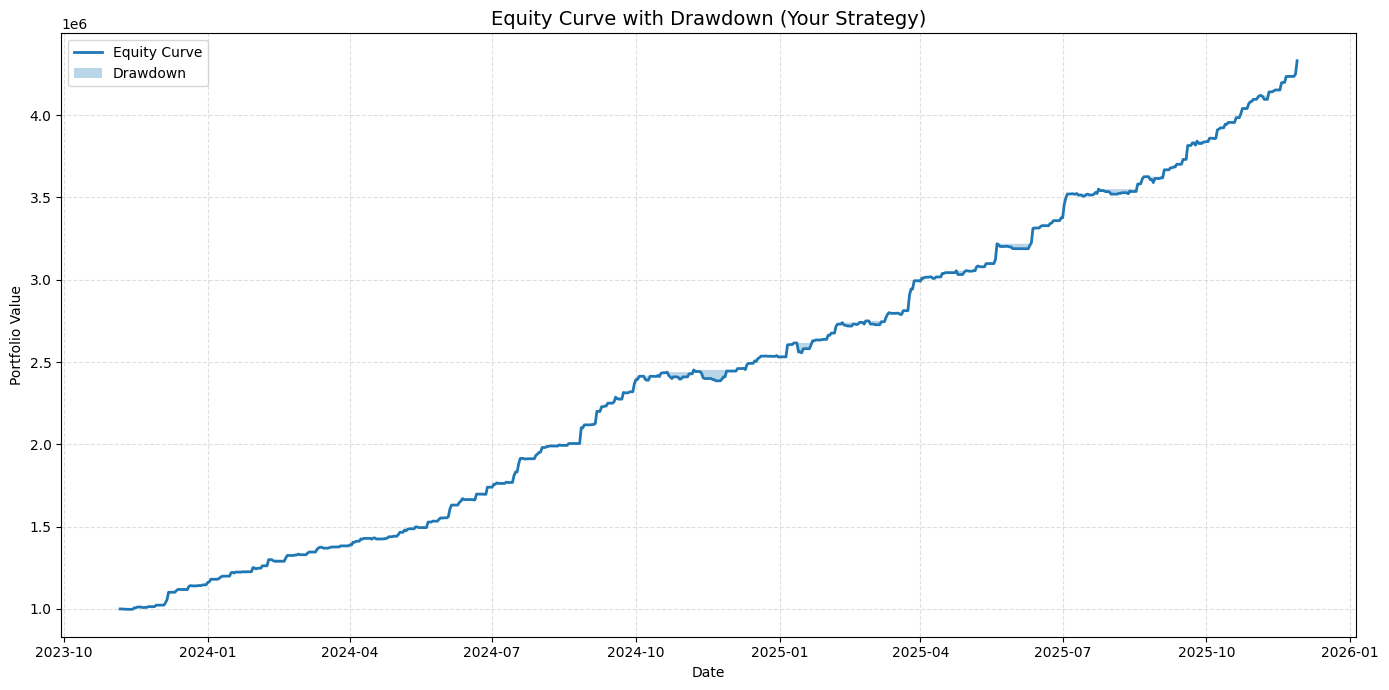


✅ ADVANCED STRATEGY METRICS

Total Trades              : 928
Wins / Losses              : 519 / 409
Hit Ratio                  : 55.93%
Avg Trade PnL (₹)          : 3521.83
Avg Win (₹)                : 8707.36
Avg Loss (₹)               : -3058.34
Expectancy (₹)             : 3521.83
Max Drawdown (₹)           : -71555.22
Calmar Ratio               : 22.14
Turnover                   : 229.45x
Avg Holding Period (days) : 7.92
Total Cost (₹)            : 18560
Cost Drag %               : 1.856%


In [27]:
import numpy as np
import pandas as pd

# -----------------------------
# BASIC ACCOUNT METRICS
# -----------------------------
initial_capital = INITIAL_CAPITAL
final_value     = final_account_value

absolute_return_pct = ((final_value / initial_capital) - 1) * 100


# -----------------------------
# EQUITY CURVE FOR METRICS
# -----------------------------
df = trade_summary.copy()

df['Buy_Date']  = pd.to_datetime(df['Buy_Date']).dt.normalize()
df['Sell_Date'] = pd.to_datetime(df['Sell_Date']).dt.normalize()

# Create date range
start = df['Buy_Date'].min()
# end   = pd.Timestamp.today().normalize()
end = pd.Timestamp('2025-11-28')
all_dates = pd.date_range(start, end)

equity_df = pd.DataFrame(index=all_dates)
equity_df['Daily_PnL'] = 0.0

# Add realized PnL on sell days
closed = df[df['Status'] != "RUNNING"]
for _, row in closed.iterrows():
    if pd.notna(row['Sell_Date']):
        equity_df.loc[row['Sell_Date'], 'Daily_PnL'] += row['Realized_PnL']

# Add unrealized PnL on last day
running = df[df['Status'] == "RUNNING"]
if not running.empty:
    equity_df.iloc[-1, 0] += running['Unrealized_PnL'].sum()

# Build equity curve
equity_df['Equity'] = initial_capital + equity_df['Daily_PnL'].cumsum()

# -----------------------------
# RETURNS + VOLATILITY
# -----------------------------
equity_df['Daily_Return'] = equity_df['Equity'].pct_change().fillna(0)

daily_vol   = equity_df['Daily_Return'].std()
annual_vol  = daily_vol * np.sqrt(252)


# -----------------------------
# CAGR
# -----------------------------
n_years = (equity_df.index[-1] - equity_df.index[0]).days / 365.25
CAGR = ((final_value / initial_capital) ** (1 / n_years) - 1) * 100


# -----------------------------
# SHARPE & SORTINO
# -----------------------------
rfr = 0.07
daily_rfr = (1 + rfr) ** (1/252) - 1

excess = equity_df['Daily_Return'] - daily_rfr

sharpe = (excess.mean() / daily_vol) * np.sqrt(252)

downside = equity_df['Daily_Return'][equity_df['Daily_Return'] < 0]
downside_vol = downside.std()

sortino = (excess.mean() / downside_vol) * np.sqrt(252)


# -----------------------------
# MAX DRAWDOWN
# -----------------------------
equity_df['Peak'] = equity_df['Equity'].cummax()
drawdown_pct = (equity_df['Equity'] - equity_df['Peak']) / equity_df['Peak'] * 100
max_drawdown = drawdown_pct.min()


# -----------------------------
# PRINT METRICS
# -----------------------------
print("\n📊 PERFORMANCE METRICS\n")

print(f"Initial Capital       : {initial_capital:,.2f}")
print(f"Final Account Value   : {final_value:,.2f}")
print(f"Net PnL               : {final_value - initial_capital:,.2f}")
print(f"Absolute Return       : {absolute_return_pct:.2f}%")

print(f"\nCAGR                   : {CAGR:.2f}%")
print(f"Annual Volatility      : {annual_vol*100:.2f}%")
print(f"Sharpe Ratio (7% RFR)  : {sharpe:.2f}")
print(f"Sortino Ratio          : {sortino:.2f}")
print(f"Maximum Drawdown       : {max_drawdown:.2f}%")
import matplotlib.pyplot as plt

# Ensure drawdown columns exist
equity_df['Peak'] = equity_df['Equity'].cummax()
equity_df['Drawdown'] = equity_df['Equity'] - equity_df['Peak']

# ---- PLOT: EQUITY CURVE + DRAWDOWN ----
plt.figure(figsize=(14, 7))

# Equity curve
plt.plot(equity_df.index, equity_df['Equity'], label='Equity Curve', linewidth=2)

# Drawdown shading
plt.fill_between(
    equity_df.index,
    equity_df['Equity'],
    equity_df['Peak'],
    where=(equity_df['Equity'] < equity_df['Peak']),
    alpha=0.3,
    label="Drawdown"
)

plt.title("Equity Curve with Drawdown (Your Strategy)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()
import numpy as np

# ----------------------------------
# WORK ONLY ON CLOSED TRADES
# ----------------------------------
closed = trade_summary[trade_summary['Status'] != 'RUNNING'].copy()

if closed.empty:
    print("\n⛔ No closed trades available for metrics.")
else:
    # Ensure datetime
    closed['Buy_Date']  = pd.to_datetime(closed['Buy_Date'])
    closed['Sell_Date'] = pd.to_datetime(closed['Sell_Date'])

    # ----------------------------------
    # BASIC COUNTS
    # ----------------------------------
    total_trades = len(closed)
    wins  = (closed['Realized_PnL'] > 0).sum()
    losses = (closed['Realized_PnL'] <= 0).sum()

    # ----------------------------------
    # HIT RATIO
    # ----------------------------------
    hit_ratio = round((wins / total_trades) * 100, 2)

    # ----------------------------------
    # AVG TRADE PNL
    # ----------------------------------
    avg_trade_pnl = round(closed['Realized_PnL'].mean(), 2)

    # ----------------------------------
    # EXPECTANCY
    # ----------------------------------
    avg_win  = closed.loc[closed['Realized_PnL'] > 0, 'Realized_PnL'].mean() if wins > 0 else 0
    avg_loss = closed.loc[closed['Realized_PnL'] <= 0, 'Realized_PnL'].mean() if losses > 0 else 0

    expectancy = round((wins/total_trades)*avg_win + (losses/total_trades)*avg_loss, 2)

    # ----------------------------------
    # MAX DRAWDOWN (FROM CUM PNL)
    # ----------------------------------
    closed['Cum_PnL'] = closed['Realized_PnL'].cumsum()
    closed['Cum_Max'] = closed['Cum_PnL'].cummax()
    closed['Drawdown'] = closed['Cum_PnL'] - closed['Cum_Max']

    max_drawdown = round(closed['Drawdown'].min(), 2)

    # ----------------------------------
    # CALMAR RATIO
    # ----------------------------------
    total_return = closed['Cum_PnL'].iloc[-1]

    # Annualization using holding period in days
    total_days = (closed['Sell_Date'].max() - closed['Buy_Date'].min()).days

    if total_days > 0:
        annual_return = (total_return / INITIAL_CAPITAL) * (365 / total_days)
    else:
        annual_return = 0

    if max_drawdown != 0:
        calmar = round(annual_return / abs(max_drawdown/INITIAL_CAPITAL), 3)
    else:
        calmar = np.inf

    # ----------------------------------
    # TURNOVER
    # ----------------------------------
    turnover = round((closed['Invested'].sum()) / INITIAL_CAPITAL, 2)

    # ----------------------------------
    # AVG HOLDING PERIOD (DAYS)
    # ----------------------------------
    closed['Holding_Days'] = (closed['Sell_Date'] - closed['Buy_Date']).dt.days
    avg_holding = round(closed['Holding_Days'].mean(), 2)

    # ----------------------------------
    # COST DRAG (OPTIONAL BROKER COST INPUT)
    # ----------------------------------
    COST_PER_TRADE = 20  # change if needed
    total_cost = COST_PER_TRADE * total_trades

    cost_drag_pct = round((total_cost / INITIAL_CAPITAL) * 100, 3)

    # ----------------------------------
    # FINAL OUTPUT
    # ----------------------------------
    print("\n✅ ADVANCED STRATEGY METRICS\n")

    print(f"Total Trades              : {total_trades}")
    print(f"Wins / Losses              : {wins} / {losses}")
    print(f"Hit Ratio                  : {hit_ratio}%")
    print(f"Avg Trade PnL (₹)          : {avg_trade_pnl}")
    print(f"Avg Win (₹)                : {round(avg_win,2)}")
    print(f"Avg Loss (₹)               : {round(avg_loss,2)}")
    print(f"Expectancy (₹)             : {expectancy}")
    print(f"Max Drawdown (₹)           : {max_drawdown}")
    print(f"Calmar Ratio               : {calmar}")
    print(f"Turnover                   : {turnover}x")
    print(f"Avg Holding Period (days) : {avg_holding}")
    print(f"Total Cost (₹)            : {total_cost}")
    print(f"Cost Drag %               : {cost_drag_pct}%")
